## Send API Dynamic Fan-out

{
    'poem': '茜空や 散るも潔し 花の雪',
    'ci_poem': '桜花の散るを見つつも立ち尽くす 君の面影春風に舞う',
    'joke': 'はい、桜をテーマにしたジョークをいくつかご紹介します。\n\n---\n\n**1. 
花見の準備**\n\n会社の同僚が言った。\n「今年の花見、場所取りは俺がやるよ。朝の4時から行って、シート広げてくるわ」\n
すると先輩が心配そうに言った。\n「おい、それは言うな。その言葉、もう『散る』って言ってるようなもんだぞ」\n\n---\n\n
**2. 
桜前線**\n\nテレビの天気予報で桜前線の話題になり、関西の男性が言った。\n「今年はいつもより早いなあ。でも、アレって
結局、北に進むほど『花冷え』するんやろ？」\n隣にいた北海道出身の友人がボソッとつぶやいた。\n「こっちはな、花冷えど
ころか『花吹雪』の後に『花散らしの雪』が待ってるんだぞ…」\n\n---\n\n**3. 
お花見の宴会**\n\n花見の席で、お酒を飲みすぎた人がうつむいている。\n友人:「どうしたんだよ、元気ないじゃないか」\n落
ち込んでいる人:「いや…さっき桜の花びらがお猪口にヒラリと落ちてきたんだよ」\n友人:「ああ、風流だなあ」\n落ち込んでい
る人:「その瞬間、『もう春も終わりだな』って悟ってしまって…。人生の儚さを感じたんだ」\n\n---\n\n**4. 
お花見の場所取り**\n\n会社の新人が張り切って言った。\n「先輩！ 
明日の花見のために、今から徹夜で場所取りしてきます！」\n先輩がマジメな顔で言う。\n「気持ちはありがたいが、お前が徹
夜したら、明日の花見で俺たちが『お前の顔色』で花より団子ならぬ『花より心配』になっちまうだろ。座ってろ」\n\n---\n\n
**5. 
植物学的な見解**\n\nある植物学者が言った。\n「桜の花って、幹から直接咲いてるように見えるけど、実はちゃんと枝分かれ
してるんですよ。あれはですね、つまり…」\nそれを聞いた友人がボソッとつぶやく。\n「で、その話、最後まで聞くと『花見の
席でドヤ顔』ってことだけは分かったわ」\n\n---\n\n**6. 
ジェットコースター**\n\n遊園地で、彼女が桜を見上げながら言った。\n「ねえ、桜ってあっという間に散っちゃうよね。まる
で恋愛と同じだね」\n彼氏が冷静に言い返す。\n「いや、あれは乗ったらすぐ終わるジェットコースターと一緒だよ。つまり、
また来年も並べば乗れるってことだ」\n\n---\n\nいかがでしょうか。春の風物詩にまつわる人間模様を描いてみました。'
}

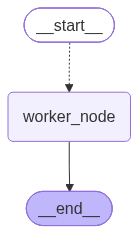

In [1]:
from typing import TypedDict, Literal, Sequence
from langchain_deepseek import ChatDeepSeek
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
from langchain.messages import HumanMessage
from dotenv import load_dotenv
from rich import print

load_dotenv(override=True)

CONTENT_TYPES = ["poem", "joke", "ci_poem"]

model = ChatDeepSeek(
    model="deepseek-v4-flash",
    extra_body={
        "thinking": {
            "type": "disabled"
        }
    }
)


#1. 状態を定義
#1.1 グローバル状態
class OverAllState(TypedDict):
    topic: str
    poem: str
    ci_poem: str
    joke: str


#1.2 プライベート状態
class workerState(TypedDict):
    content_type: Literal["poem", "joke", "ci_poem"]
    prompt: str


#1.3 入力状態
class inputState(TypedDict):
    topic: str


#1.4 出力状態
class outputState(TypedDict):
    poem: str
    ci_poem: str
    joke: str


# 2. ノードを定義
def worker_node(state: workerState) -> outputState:
    content_type = state["content_type"]
    prompt = state["prompt"]
    content = model.invoke([HumanMessage(prompt)]).content
    return {
        content_type: content
    }


#3. 動的分岐のルーターを定義
def router(state: inputState) -> Sequence[Send]:
    router_prompt = "{} をテーマにした{}を生成してください"
    english2Chinese = {
        "poem": "俳句",
        "joke": "ジョーク",
        "ci_poem": "短歌"
    }
    topic = state["topic"]
    return [
        Send(
            "worker_node",
            {
                "content_type": content_type,
                "prompt": router_prompt.format(topic, english2Chinese[content_type])
            }
        )
        for content_type in CONTENT_TYPES
    ]


#4. グラフを構築
builder = StateGraph(state_schema=OverAllState, input_schema=inputState, output_schema=outputState)

builder.add_node("worker_node", worker_node)

builder.add_conditional_edges(
    START,
    router,
    path_map=["worker_node"],
)

builder.add_edge("worker_node", END)

graph = builder.compile()
res = graph.invoke({"topic": "桜"})
print(res)

from IPython.display import display

display(graph)